In [1]:
!pip install -q ipywidgets
!apt-get install -q -y graphviz graphviz-dev && pip install -q pydot
!pip install -q pygraphviz

Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  libxcomposite1 libxdot4
0 upgraded, 11 newly installed, 0 to remove and 83 not upgraded.
Need to get 2,478 kB of archives.
After this operation, 7,871 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-0 amd64 2.36.0-3build1 [51.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main am

In [2]:
## -- System dependencies --
import tensorflow as tf
import sys, os, gc
import torch
import pydot

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [3]:
# os.environ['KERAS_BACKEND'] = 'tensorflow'

In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools
import shutil

## -- Machine Learning --
import sklearn
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.isotonic import IsotonicRegression
from sklearn.compose import make_column_transformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, log_loss, brier_score_loss
from sklearn.preprocessing import StandardScaler, TargetEncoder, OneHotEncoder, LabelEncoder, label_binarize

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# tf.keras.utils.set_random_seed(CFG['SEED'])
# warnings.filterwarnings("ignore", message="Setting the random state for TF")
tf.get_logger().setLevel('ERROR')

In [5]:
## -- Global Settings --
# sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style('whitegrid')
# plt.style.use("ggplot")

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

## -- Set Global Seed --
CFG = {
    'FOLDS':  5,
    'SEED':   42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e7/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = '/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/'
    orig = pd.read_csv(ORIG_PATH+'student_health_dataset_50k.csv')
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e7 | Student Health/_student_health_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')
    orig = pd.read_csv(PATH+'student_health_dataset_50k.csv')

## =================================================================================

ID = 'id'
TARGET  = 'health_condition'
OBJECTS = train.select_dtypes(include=['object', 'category']).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

NUM_CLASSES = train[TARGET].nunique()

# {c: i for i, c in enumerate(train[TARGET].unique())}
mapping   = {'fit': 0, 'at-risk': 1, 'unhealthy': 2}
r_mapping = {v: k for k, v in mapping.items()}

train[TARGET] = train[TARGET].map(mapping)
orig[TARGET]  = orig[TARGET].map(mapping)

for (name, df) in {'Train': train, 'Test': test, 'Orig': orig}.items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (690088, 15)
Test shape: (295753, 14)
Orig shape: (50000, 16)

Total Numerical: 7
Total Categorical: 6
Total base features: 13


In [7]:
display(train.head())
train.info()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  int64  
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,690088.0,345043.500000,199211.390620,0.0,172521.75,345043.50,517565.25,690087.00
health_condition,690088.0,1.025969,0.375035,0.0,1.00,1.00,1.00,2.00
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
Train,701,537,1596,2101,12807,856,400,3,3,3,3,3,3
Original,700,585,1627,2179,13601,1041,412,3,3,3,3,3,3
Test,692,526,1548,2068,12196,817,392,3,3,3,3,3,3


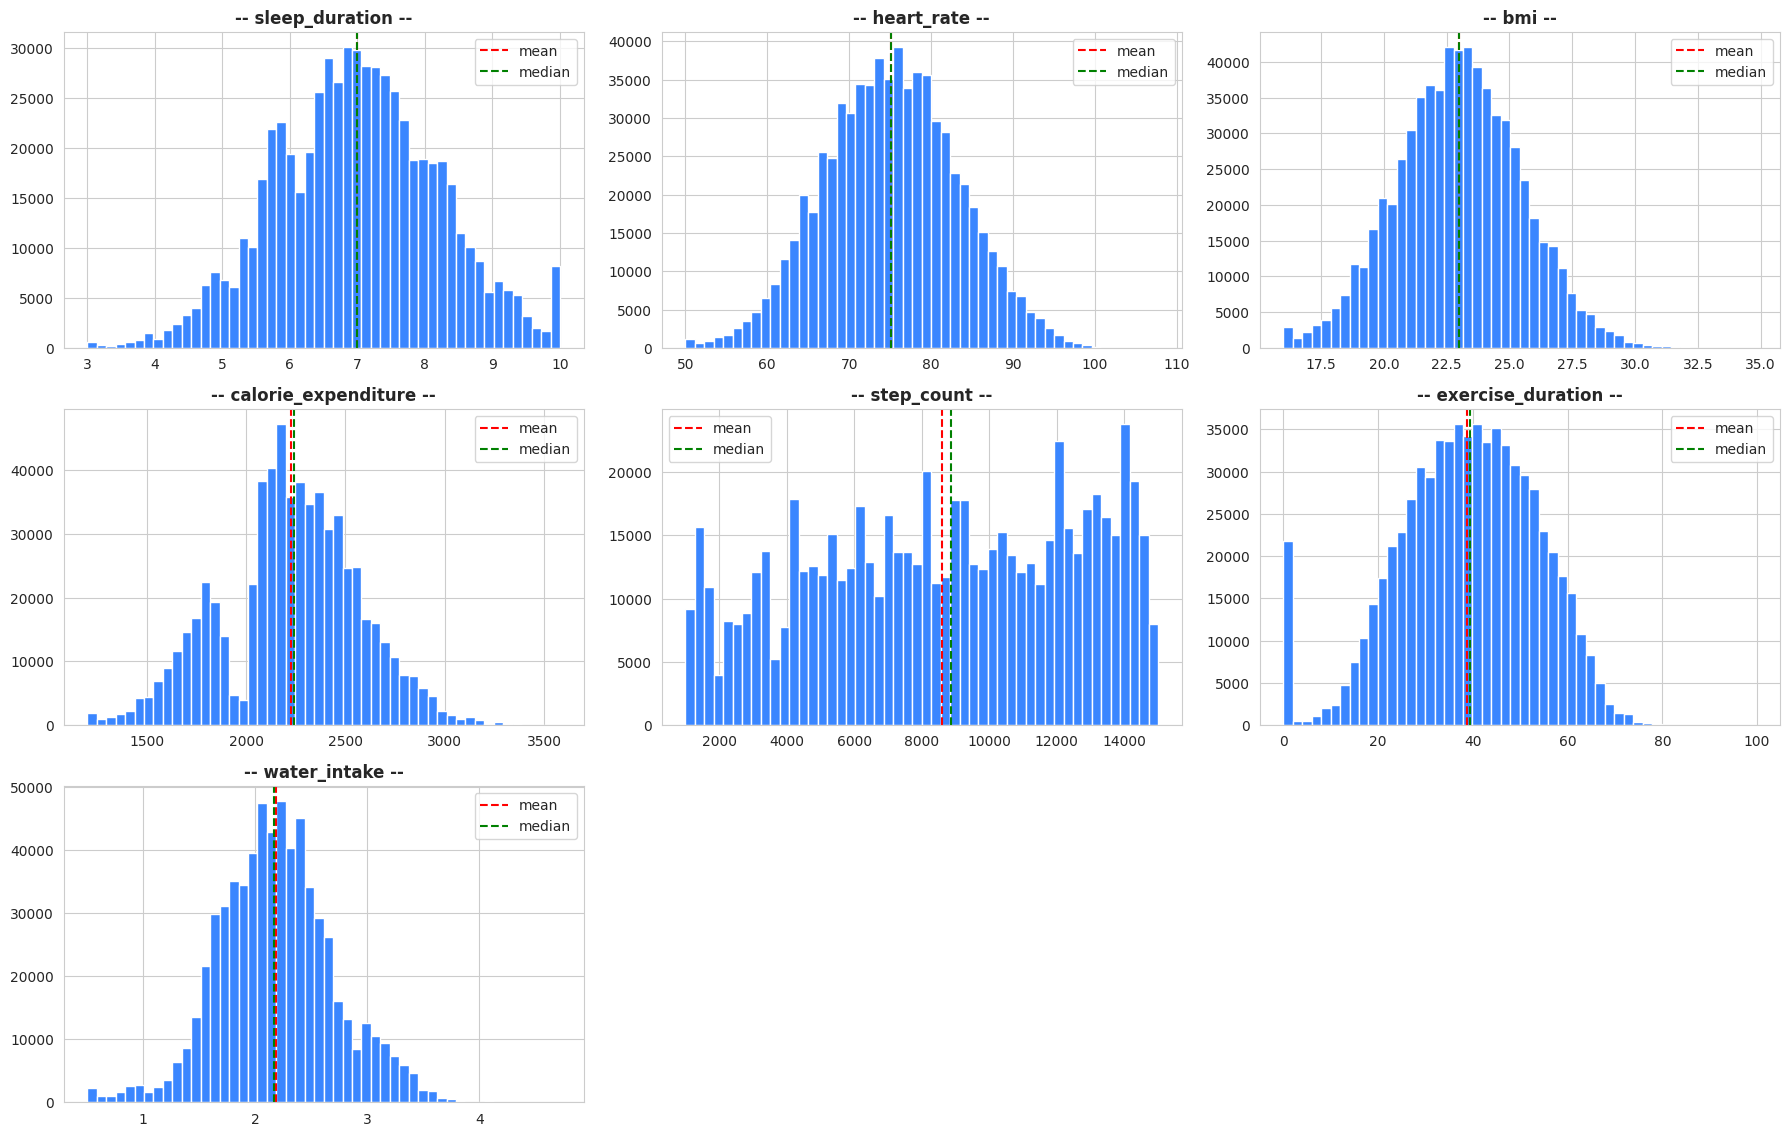

In [10]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'-- {col} --', fontweight='semibold')
    plt.legend()

plt.tight_layout()
plt.show()

In [11]:
def get_class_weights(y):
    """
    y: Current y labels -> numpy array or series
    """
    cls_ = np.unique(y)
    wts_ = compute_class_weight('balanced', classes=cls_, y=y)
    return dict(zip([c for c in cls_], wts_))

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
        cls_wts = dict(zip(cls_, wts_))
        return np.array([cls_wts[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def multi_class_brier(y_true, y_proba, classes):
    y_onehot = label_binarize(y_true, classes=classes)
    return float(np.mean(np.sum((y_onehot - y_proba) ** 2, axis=1)))


def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED']).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

print("- Helper functions ready -")

- Helper functions ready -


## FEATURE ENGINEERING

In [12]:
get_class_weights(train[TARGET])

{np.int64(0): np.float64(5.779195873007898),
 np.int64(1): np.float64(0.38819519565636845),
 np.int64(2): np.float64(3.9849860254544613)}

In [13]:
## -- Extractions & Binnig --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []
 
round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [14]:
# for col in ['redshift']:
#     # print(f"\nRounding... ", end='')
#     # for r in range(-3, 6):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     # print(f"\nDigitizing... ", end='')
#     # for d in range(1):
#     #     d_n = f'{col}_{d}_digit_'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nEqual binning... ", end='')
#     # for b in [32, 64, 128]: # 100, 500, 1000
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     print(f"\nQuantile binning... ", end='')
#     for q in [4]:
#         q_n = f'{col}_Qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [15]:
# for col in ['delta', 'alpha']: # 'u', 'g', 'r', 'i', 'z',
#     # print(f"\nRounding... ", end='')
#     # for r in range(-3, 5):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)
    
#     # print(f"\nExtracting digits... ", end='')
#     # for d in range(-3, 6):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nEqual binning... ", end='')
#     # for b in [100]: # 50, 100, 400
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     # Fit on train data and transform both train and test
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)
        
#     print(f"\nQuantile binning.. ", end='')
#     for q in [100]: 
#         q_n = f'{col}_qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [16]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [17]:
# plt.figure(figsize=(18, 5))
# ax = (train.groupby(by=Q_BINS[0])[TARGET].mean() / 3).plot(linestyle='-.', label=Q_BINS[0])
# (train.groupby(by=Q_BINS[1])[TARGET].mean() / 3).plot(linestyle='-.', ax=ax, label=Q_BINS[1])

# plt.legend()
# plt.show()

In [18]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         # 1. Get value counts
#         v_counts = df[c].value_counts()
#         # 2. Identify values to replace (count <= threshold)
#         to_replace = v_counts[v_counts <= thresh].index
#         # 3. Apply condition: if value in low-freq list, assign 0, else keep it
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [19]:
# ## -- Arithmetic interaction --
# # u - g, g - r, r - i, i - z

# # ('u', 'g'),
# # ('g', 'r'),
# # ('g', 'i'),
# # ('i', 'z'),
# # ('r', 'z')

# for df in tqdm([train, test, orig]):
#     df['u_g_sub_'] = df['u'] - df['g']
#     df['g_r_sub_'] = df['g'] - df['r']

#     df['g_i_sub_'] = df['g'] - df['i']
#     df['r_z_sub_'] = df['r'] - df['z']

#     df['i_z_sub_'] = df['i'] - df['z']
#     df['r_i_sub_'] = df['r'] - df['i']
    
#     df['stellar_locus_dist'] = np.sqrt((df['g_r_sub_'] - 0.52)**2 + (df['r_i_sub_'] - 0.25)**2)

#     for band in ['g', 'i']:
#         b_col = f"_{band}_redshift_div_"
#         df[b_col] = df[band] / (df['redshift'] + 1e-6)

# color_bands = [c for c in train.columns if c.endswith('_sub_') or c.endswith('_div_')]
# color_bands.append('stellar_locus_dist')

# train[color_bands].describe()

In [20]:
# ## -- Cyclic encoding --

# for df in [train, test, orig]:
#     for col in ['alpha']:
#         for p in [180, 360]:
#             df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
#             df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

# for df in [train, test, orig]:
#     for col in ['delta']:
#         for p in [180]:
#             df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
#             df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

# cyclic_cols = [c for c in train.columns if c.endswith('_sin_') or c.endswith('_cos_')]

# train[cyclic_cols].head()

In [21]:
# plt.figure(figsize=(18, 15))
# sns.heatmap(train[].corr(), annot=True) # cyclic_cols+color_bands
# plt.show()

In [22]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreate frequencies... ", end='')
# for col in ['spectral_type']:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print()
# print(f"✅ Total frequency features: {len(freq_cols)}")

# train[freq_cols].head()

In [23]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     print(f"Paired: {n_col}... ", end='')
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_COLS, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(TOP_COLS, LOW_COLS)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print()
# print(f"Total interaction features: {len(INTER)}")

# train[INTER].head()

In [24]:
# ## -- Create log-transformed features --
# for df in [train, test, orig]:
#     for col in ['redshift',]:
#         n_log = f"_log_{col}"
#         df[n_log] = np.log1p(df[col])

# log_cols = [c for c in train.columns if c.startswith('_log_')]

# plt.figure(figsize=(18, 5))
# for i, col in enumerate(log_cols):
#     # plt.subplot(2, len(log_cols)//2, i+1)
#     plt.hist(train[col], bins=100)
#     plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
#     plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
#     plt.title(f'{col}', fontweight='semibold')
#     plt.legend()

# plt.tight_layout()
# plt.show()

In [25]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/CategoryMean ENCODERS =====

# class TargetEncoder(BaseEstimator, TransformerMixin):
#     """
#     Target Encoder that supports multiple aggregation functions,
#     internal cross-validation for leakage prevention, and smoothing.

#     Parameters
#     ----------
#     cols_to_encode : list of str
#         List of column names to be target encoded.

#     aggs : list of str, default=['mean']
#         List of aggregation functions to apply. Any function accepted by
#         pandas' `.agg()` method is supported, such as:
#         'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
#         'count', 'sum', 'median'.
#         Smoothing is applied only to the 'mean' aggregation.

#     cv : int, default=5
#         Number of folds for cross-validation in fit_transform.

#     smooth : float or 'auto', default='auto'
#         The smoothing parameter `m`. A larger value puts more weight on the
#         global mean. If 'auto', an empirical Bayes estimate is used.

#     drop_original : bool, default=False
#         If True, the original columns to be encoded are dropped.
#     """
#     def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
#         self.cols_to_encode = cols_to_encode
#         self.aggs = aggs
#         self.cv = cv
#         self.smooth = smooth
#         self.drop_original = drop_original
#         self.mappings_ = {}
#         self.global_stats_ = {}

#     def fit(self, X, y):
#         """
#         Learn mappings from the entire dataset.
#         These mappings are used for the transform method on validation/test data.
#         """
#         temp_df = X.copy()
#         temp_df['target'] = y

#         # Learn global statistics for each aggregation
#         for agg_func in self.aggs:
#             self.global_stats_[agg_func] = y.agg(agg_func)

#         # Learn category-specific mappings
#         for col in self.cols_to_encode:
#             self.mappings_[col] = {}
#             for agg_func in self.aggs:
#                 mapping = temp_df.groupby(col)['target'].agg(agg_func)
#                 self.mappings_[col][agg_func] = mapping

#         return self

#     def transform(self, X):
#         """
#         Apply learned mappings to the data.
#         Unseen categories are filled with global statistics.
#         """
#         X_transformed = X.copy()
#         for col in self.cols_to_encode:
#             for agg_func in self.aggs:
#                 new_col_name = f'TE_{col}_{agg_func}'
#                 map_series = self.mappings_[col][agg_func]
#                 X_transformed[new_col_name] = X[col].map(map_series)
#                 X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)

#         return X_transformed

#     def fit_transform(self, X, y):
#         """
#         Fit and transform the data using internal cross-validation to prevent leakage.
#         """
#         # First, fit on the entire dataset to get global mappings for transform method
#         self.fit(X, y)

#         # Initialize an empty DataFrame to store encoded features
#         encoded_features = pd.DataFrame(index=X.index)

#         kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

#         for train_idx, val_idx in kf.split(X, y):
#             X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#             X_val = X.iloc[val_idx]

#             temp_df_train = X_train.copy()
#             temp_df_train['target'] = y_train

#             for col in self.cols_to_encode:
#                 # --- Calculate mappings only on the training part of the fold ---
#                 for agg_func in self.aggs:
#                     new_col_name = f'TE_{col}_{agg_func}'

#                     # Calculate global stat for this fold
#                     fold_global_stat = y_train.agg(agg_func)

#                     # Calculate category stats for this fold
#                     mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

#                     # --- Apply smoothing only for 'mean' aggregation ---
#                     if agg_func == 'mean':
#                         counts = temp_df_train.groupby(col)['target'].count()

#                         m = self.smooth
#                         if self.smooth == 'auto':
#                             # Empirical Bayes smoothing
#                             variance_between = mapping.var()
#                             avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
#                             if variance_between > 0:
#                                 m = avg_variance_within / variance_between
#                             else:
#                                 m = 0  # No smoothing if no variance between groups

#                         # Apply smoothing formula
#                         smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
#                         encoded_values = X_val[col].map(smoothed_mapping)
#                     else:
#                         encoded_values = X_val[col].map(mapping)

#                     # Store encoded values for the validation fold
#                     encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

#         # Merge with original DataFrame
#         X_transformed = X.copy()
#         for col in encoded_features.columns:
#             X_transformed[col] = encoded_features[col]

#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)

#         return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [26]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [27]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE, #+ROUNDS+DIGITS, #+ROUNDS,
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     fill_nan=True,
# )

In [28]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# for c in BASE:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- FACTORIZE CATS_2 --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     v = combine.factorize()[0]
#     train[n] = v[:len(train)].astype('int32')
#     test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'Numericals to Categoricals: {len(CATS_2)}')

In [29]:
# ## -- Factorize using combined data --
# for c in ['galaxy_population']: # CATS
#     combine  = pd.concat([train[c], test[c], orig[c]])
#     combine  = combine.factorize()[0]
#     # combine  = pd.Series(combine).astype('category')
#     train[c] = combine[:len(train)].astype('float')
#     test[c]  = combine[len(train):len(train)+len(test)].astype('float')
#     orig[c]  = combine[-len(orig):].astype('float')

# print('Label encoding complete!')

In [30]:
## -- Fill categorical --
train[CATS] = train[CATS].fillna('missing')
test[CATS]  = test[CATS].fillna('missing')
orig[CATS]  = orig[CATS].fillna('missing')

## -- Get NaN indicators --
def appy_nan_indicator(df):
    df1 = df.copy()
    cols_with_nan = df1.columns[df1.isna().any()]
    indicators = df1[cols_with_nan].isna().astype(float).add_prefix('isna_')
    indi_cols = indicators.columns.tolist()
    df1 = df1.join(indicators)

    return df1, indi_cols

train, INDI_COLS = appy_nan_indicator(train)
test, _  = appy_nan_indicator(test)
orig, _  = appy_nan_indicator(orig)

print(INDI_COLS)
train

['isna_sleep_duration', 'isna_heart_rate', 'isna_bmi', 'isna_calorie_expenditure', 'isna_step_count', 'isna_exercise_duration', 'isna_water_intake']


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,isna_sleep_duration,isna_heart_rate,isna_bmi,isna_calorie_expenditure,isna_step_count,isna_exercise_duration,isna_water_intake
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,missing,average,sedentary,missing,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,1,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female,0.0,0.0,0.0,0.0,1.0,0.0,0.0
690084,690084,1,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690085,690085,0,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,missing,average,active,no,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690086,690086,1,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,missing,average,active,yes,male,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
## -- Ohe-Hot encode CATS --
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]

combine = pd.concat([train[FEATURES], test[FEATURES]])
combine_ohe = pd.get_dummies(combine, columns=CATS, dtype='float', drop_first=False)

train_enc = combine_ohe[:len(train)]
train = pd.concat([train_enc, train[TARGET]], axis=1)
test = combine_ohe[len(train):]

del combine_ohe

print(f'One-hot complete!\nExpanded features: {test.shape[1]}')
train.head()

One-hot complete!
Expanded features: 38


,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,isna_sleep_duration,isna_heart_rate,isna_bmi,isna_calorie_expenditure,isna_step_count,isna_exercise_duration,isna_water_intake,diet_type_balanced,diet_type_missing,diet_type_non-veg,diet_type_veg,stress_level_high,stress_level_low,stress_level_medium,stress_level_missing,sleep_quality_average,sleep_quality_good,sleep_quality_missing,sleep_quality_poor,physical_activity_level_active,physical_activity_level_missing,physical_activity_level_moderate,physical_activity_level_sedentary,smoking_alcohol_missing,smoking_alcohol_no,smoking_alcohol_occasional,smoking_alcohol_yes,gender_female,gender_male,gender_missing,gender_other,health_condition
0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2
1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2
3,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2
4,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1


In [32]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print('Total Features:', len(FEATURES))

train

Total Features: 38


,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,isna_sleep_duration,isna_heart_rate,isna_bmi,isna_calorie_expenditure,isna_step_count,isna_exercise_duration,isna_water_intake,diet_type_balanced,diet_type_missing,diet_type_non-veg,diet_type_veg,stress_level_high,stress_level_low,stress_level_medium,stress_level_missing,sleep_quality_average,sleep_quality_good,sleep_quality_missing,sleep_quality_poor,physical_activity_level_active,physical_activity_level_missing,physical_activity_level_moderate,physical_activity_level_sedentary,smoking_alcohol_missing,smoking_alcohol_no,smoking_alcohol_occasional,smoking_alcohol_yes,gender_female,gender_male,gender_missing,gender_other,health_condition
0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2
1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2
3,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2
4,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1
690084,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1
690085,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0
690086,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1


In [33]:
# plt.figure(figsize=(18, 15))
# sns.heatmap(train.corr('spearman'), annot=True, fmt='.2f', cbar=False, center=0)
# plt.show()

In [34]:
# ## -- Ohe-Hot encode DIGITS --
# FEATURES = [c for c in train.columns if c not in ['id', TARGET]]

# combine = pd.concat([train[FEATURES], test[FEATURES]])
# combine_ohe = pd.get_dummies(combine, columns=DIGITS, dtype='int8', drop_first=False)

# train_enc = combine_ohe[:len(train)]
# test = combine_ohe[len(train):]

# train = pd.concat([train_enc, train[TARGET]], axis=1)

# print(f'One-Hot Encoding complete!\nExpanded Features: {combine_ohe.shape[1]}')
# combine_ohe.head(3)

In [35]:
# FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
# NEW_CATS = [c for c in FEATURES if col.endswith('_')]
# NEW_NUMS = [c for c in FEATURES if col.startswith('_')]

# print('Total Features:', len(FEATURES))
# print('Total Cat Cols:', len(NEW_CATS))
# print('Total Num Cols:', len(NEW_NUMS))

# train.head(3)

In [36]:
for col in FEATURES:
    if train[col].nunique() == 1:
        print('Has constant values', col)

# ML TRAINING

In [37]:
try:
    from scikeras.wrappers import KerasClassifier
except:
    %pip install -q -U scikeras
    from scikeras.wrappers import KerasClassifier

Note: you may need to restart the kernel to use updated packages.


In [38]:
try:
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression
except:
    %pip install -q venn-abers
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression

try:
    import skrub
except:
    %pip install -q skrub
    import skrub

  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.9/585.9 kB 11.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [39]:
def build_keras_model(shape, lr, drop, units):
    kernel_reg = tf.keras.regularizers.L2(0.0)
    use_bias   = True
    act        = "relu"

    # 2. Create the Sequential model
    model = tf.keras.Sequential([
        tf.keras.Input(shape=shape),
        # Optional: Add BN here if your data isn't pre-scaled
        # tf.keras.layers.BatchNormalization(),

        ## -- 1st Layer --
        tf.keras.layers.Dense(units[0], act, use_bias=use_bias,
                           kernel_regularizer=kernel_reg),
        tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop),

        ## -- 2nd Layer --
        tf.keras.layers.Dense(units[1], act, use_bias=use_bias,
                           kernel_regularizer=kernel_reg),
        tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop),

        ## -- 3rd Layer --
        tf.keras.layers.Dense(units[2], act, use_bias=use_bias,
                           kernel_regularizer=kernel_reg),
        tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop),

        ## -- Output --
        tf.keras.layers.Dense(len(mapping), activation='softmax')
    ])

    model.compile(
        # optimizer=tf.keras.optimizers.RMSprop(lr),
        optimizer=tf.keras.optimizers.Adam(lr, weight_decay=0.0),

        ## - one-hot encoded category
        # loss=tf.keras.losses.CategoricalCrossentropy(name='loss'),
        # metrics=[tf.keras.metrics.CategoricalAccuracy(name='accuracy')],

        ## - single frame integers
        loss=tf.keras.losses.SparseCategoricalCrossentropy(name='loss'),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')],
    )

    return model

print("⚙️ Keras model ready ⚙️")

⚙️ Keras model ready ⚙️


In [40]:
## -- DEFINE TRAINER (Option for CALIBRATION) --
class TrainerCV:
    def __init__(
        self,
        model_builder, # function(input_shape, batch_size, epochs, lr, **kwargs) -> tf.keras.Model
        kfold, # e.g., StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        model_name: str,
        train_df: pd.DataFrame,
        test_df: pd.DataFrame,
        features: list,
        target: str,
        batch_size: int =32,
        units= [256, 128, 32],
        epochs: int =10,
        patience: int =3,
        activation: str ="relu",
        learning_rate: float =1e-2,
        dropout: float =0.3,
        eval_metric: str ="val_loss",
        use_calibration: bool =False,
        **kwargs
    ):
        self.model_builder = model_builder
        self.kfold = kfold
        self.model_name = model_name
        self.train_df = train_df
        self.test_df = test_df
        self.features = features
        self.target = target
        self.batch_size = batch_size
        self.units = units
        self.epochs = epochs
        self.patience = patience
        self.activation = activation
        self.learning_rate = learning_rate
        self.dropout = dropout
        self.eval_metric = eval_metric
        self.use_calibration = use_calibration

        self.result = None

    # def _prepare_fold_data(self, X, y, X_val=None, y_valid=None):
    #     # This helper can be extended if you want to apply masks or augmentation.
    #     return X, y

    # def _df_to_ds(self, df_full, target, batch_input):
    #     df = df_full.copy()
    #     labels = df.pop(target)
    #     ds = tensorflow.data.Dataset.from_tensor_slices((dict(df), labels))
    #     ds = ds.batch(batch_input)
    #     return ds


    def fit(self):
        train_df = self.train_df
        test_df  = self.test_df
        features = self.features
        target   = self.target

        print(f"\n===== Starting CV: {self.model_name} =====")
        start = time()


        X = train_df[features]
        y = train_df[target]
        num_cls = y.nunique()

        self.oof_preds   = np.zeros((len(train_df), num_cls))
        self.test_preds  = np.zeros((len(test_df), num_cls))
        self.fold_scores = []
        self.histories_  = []

        strategy = tf.distribute.MirroredStrategy()
        GLOBAL_BATCH_SIZE = self.batch_size * strategy.num_replicas_in_sync
        print('⚙️ Number of devices: {}'.format(strategy.num_replicas_in_sync))

        for idx, (train_idx, val_idx) in enumerate(self.kfold.split(X, y), 1):
            print(f"\n * FOLD {idx}/{self.kfold.n_splits} | Calibrate: {str(self.use_calibration)}", end="")

            X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
            X_test = test_df[features].copy()

            ## -- Standardized data --
            for col in NUMS:
                scaler = StandardScaler()
                X_train[col] = scaler.fit_transform(X_train[[col]])
                X_valid[col] = scaler.transform(X_valid[[col]])
                X_test[col]  = scaler.transform(X_test[[col]])

                imputer = IterativeImputer(max_iter=50, tol=1e-5, random_state=0)
                X_train[col] = imputer.fit_transform(X_train[[col]])
                X_valid[col] = imputer.transform(X_valid[[col]])
                X_test[col]  = imputer.transform(X_test[[col]])

            # ## -- Target Encoding -- 
            # te_cols = INTER
            # print(f" • Target Encoding {len(te_cols)} features... ")
            # X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=True)

            ## -- Define callbacks --
            callbacks = [
                # tf.keras.callbacks.EarlyStopping(
                #     monitor=self.eval_metric,
                #     mode="max",
                #     patience=self.patience,
                #     restore_best_weights=True,
                # ),
                # tf.keras.callbacks.ReduceLROnPlateau( # dynamic adjust lr
                #     monitor=self.eval_metric,
                #     mode='max',
                #     factor=0.5,
                #     patience=5,
                #     min_lr=1e-6,
                #     verbose=1
                # ),
                tf.keras.callbacks.ModelCheckpoint( # -> save model
                    filepath=f"{CHECKPOINT}best_model.model.keras",
                    monitor=self.eval_metric,
                    mode="max",
                    save_best_only=True,
                    # verbose=1
                ),
                tf.keras.callbacks.ModelCheckpoint( # -> save weights
                    filepath=f"{CHECKPOINT}best_model.weights.h5",
                    monitor=self.eval_metric,
                    mode="max",
                    save_best_only=True,
                    save_weights_only=True,
                ),
            ]

            ## -- Build model --
            keras_clf = KerasClassifier(
                self.model_builder,
                model__shape=X_train.shape[1:],
                epochs=self.epochs,
                model__lr=self.learning_rate,
                model__drop=self.dropout,
                model__units=self.units,
                class_weight='balanced', # get_class_weights(y_train),
                batch_size=GLOBAL_BATCH_SIZE,
                callbacks=callbacks,
                # validation_batch_size=10240,
                # validation_split=0.0,
                shuffle=True,
                run_eagerly=False,
                verbose=2,
                random_state=CFG['SEED'],
            )

            if self.use_calibration:
                ## -- Internal Split for Calibration --
                X_base, X_calib, y_base, y_calib = train_test_split(
                    X_train, y_train, train_size=0.7,
                    stratify=y_train, random_state=CFG['SEED'],
                )
                print(f" | Train shape: {X_base.shape}")
                print(f" • Training base model... ")
                keras_clf.fit(
                    X_base, y_base,
                    validation_data=(X_valid, y_valid),
                    # sample_weight=get_sample_weights(y_train, y_train)
                )

                base_score = balanced_acc(y_valid, keras_clf.predict_proba(X_valid))
                base_loss  = log_loss(y_valid, keras_clf.predict_proba(X_valid))
                self.histories_.append(keras_clf.history_)

                print(f" • Calibrating {venn_type} | {X_calib.shape}... ")

                vao = VennAbersCalibrator() # - Get OOF predictions --
                oof_calib = vao.predict_proba(p_cal=keras_clf.predict_proba(X_calib),
                                              y_cal=y_calib.to_numpy(),
                                              p_test=keras_clf.predict_proba(X_valid),
                                              va_type="one_vs_all")
                self.oof_preds[val_idx] = oof_calib

                vat = VennAbersCalibrator() # - Get TEST predictions --
                test_calib = vat.predict_proba(p_cal=keras_clf.predict_proba(X_calib),
                                               y_cal=y_calib.to_numpy(),
                                               p_test=keras_clf.predict_proba(X_test),
                                               va_type="one_vs_all")
                self.test_preds += test_calib

                fold_score = balanced_acc(y_valid, self.oof_preds[val_idx])
                fold_loss = log_loss(y_valid, self.oof_preds[val_idx])
                self.fold_scores.append(fold_score)

                print(f"{CFG['YELLOW']} • Fold {idx+1} results -------------")
                print(f"model acc: {base_score:.5f} | loss: {base_loss:.5f} ")
                print(f"calib acc: {fold_score:.5f} | loss: {fold_loss:.5f}{CFG['RESET']}")
            else:
                print(f" | Train shape: {X_train.shape}")
                print(f" • Training model... ")
                keras_clf.fit(
                    X_train, y_train,
                    validation_data=(X_valid, y_valid),
                    # sample_weight=get_sample_weights(y_train, y_train)
                )
    
                self.histories_.append(keras_clf.history_)
    
                ## -- Get predictions --
                self.oof_preds[val_idx] = keras_clf.predict_proba(X_valid)
                self.test_preds += keras_clf.predict_proba(X_test)
                
                ## -- Get performance scores --
                fold_score = balanced_acc(y_valid, self.oof_preds[val_idx])
                fold_loss  = log_loss(y_valid, self.oof_preds[val_idx])
                self.fold_scores.append(fold_score)
    
                print(f"{CFG['YELLOW']}Fold {idx} acc: {fold_score:.5f} | loss: {fold_loss:.5f}{CFG['RESET']}")

        ## -- Average test predictions --
        self.test_preds /= self.kfold.n_splits

        ## -- CV results --
        print("\n========================================")
        print(f"{self.kfold.n_splits}-FOLD CV: {self.model_name}")
        print("========================================")

        for i, score in enumerate(self.fold_scores, 1):
            print(f" • Fold {i}: {score:.5f}")

        oof_score = np.round(balanced_acc(y, self.oof_preds), 5)

        print(f"{'='*40}")
        print(f"OOF score: {oof_score}")
        print(f"AVG score: {np.mean(self.fold_scores):.5f} ± {np.std(self.fold_scores):.5f}")
        print(f"{'='*40}")
        print(f'{((time() - start) / 60):.2f} mins\n')

        return {
            'oof_preds': self.oof_preds,
            'test_preds': self.test_preds,
            'oof_score': oof_score,
            'fold_scores': self.fold_scores,
            'val_data': [X_valid, y_valid],
            'history': self.histories_,
        }

print("⚙️ Model trainer ready ⚙️")

⚙️ Model trainer ready ⚙️


In [41]:
USE_FULL_TRAIN  = True
USE_CALIBRATION = False

all_predictions = {}

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,isna_sleep_duration,isna_heart_rate,isna_bmi,isna_calorie_expenditure,isna_step_count,isna_exercise_duration,isna_water_intake,diet_type_balanced,diet_type_missing,diet_type_non-veg,diet_type_veg,stress_level_high,stress_level_low,stress_level_medium,stress_level_missing,sleep_quality_average,sleep_quality_good,sleep_quality_missing,sleep_quality_poor,physical_activity_level_active,physical_activity_level_missing,physical_activity_level_moderate,physical_activity_level_sedentary,smoking_alcohol_missing,smoking_alcohol_no,smoking_alcohol_occasional,smoking_alcohol_yes,gender_female,gender_male,gender_missing,gender_other,health_condition
0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2
1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2
3,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2
4,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1
690084,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1
690085,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0
690086,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1


In [42]:
# !rm -r /kaggle/working

In [43]:
!rm -r {CHECKPOINT}

rm: cannot remove '{CHECKPOINT}': No such file or directory


In [44]:
if PLATFORM == 'kaggle':
    CHECKPOINT = '/kaggle/working/checkpoints/'
elif PLATFORM == 'colab':
    CHECKPOINT = '/content/checkpoints'

!mkdir {CHECKPOINT}

print(f"☑️ Checkpoint directory: {CHECKPOINT}")

☑️ Checkpoint directory: /kaggle/working/checkpoints/


In [45]:
%%time

LR         = 0.001
EPOCHS     = 50
PATIENCE   = 0
BATCH_SIZE = 256
DROPOUT    = 0.2
DIMENSIONS = [128, 256, 64]
ACTIVATION = 'relu'
VAL_METRIC = 'val_accuracy'

VERS = f"scikeras_calib" if USE_CALIBRATION else f"scikeras"

# for VALUE in ['relu', 'selu', 'silu', 'gelu']:
trainer = TrainerCV(
    model_builder   = build_keras_model,
    model_name      = VERS,
    train_df        = train_data,
    test_df         = test,
    features        = FEATURES,
    target          = TARGET,
    kfold           = skf,
    learning_rate   = LR,
    epochs          = EPOCHS,
    dropout         = DROPOUT,
    patience        = PATIENCE,
    activation      = ACTIVATION,
    batch_size      = BATCH_SIZE,
    units           = DIMENSIONS,
    eval_metric     = VAL_METRIC,
    use_calibration = USE_CALIBRATION,
)

result = trainer.fit()
    # all_predictions[f"{VERS}_{VALUE}"] = result['oof_score']

load_model = tf.keras.models.load_model(f"{CHECKPOINT}best_model.model.keras")
load_model.summary()


===== Starting CV: scikeras =====
⚙️ Number of devices: 1


2026-07-20 22:42:52.790888: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



 * FOLD 1/5 | Calibrate: False | Train shape: (552070, 38)
 • Training model... 
Epoch 1/50


2026-07-20 22:42:54.434759: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-07-20 22:43:15.056989: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

2157/2157 - 23s - 11ms/step - accuracy: 0.8838 - loss: 0.2679 - val_accuracy: 0.9138 - val_loss: 0.2698
Epoch 2/50
2157/2157 - 19s - 9ms/step - accuracy: 0.9268 - loss: 0.2041 - val_accuracy: 0.9209 - val_loss: 0.2509
Epoch 3/50
2157/2157 - 18s - 8ms/step - accuracy: 0.9304 - loss: 0.1952 - val_accuracy: 0.9242 - val_loss: 0.2436
Epoch 4/50
2157/2157 - 18s - 8ms/step - accuracy: 0.9324 - loss: 0.1904 - val_accuracy: 0.9253 - val_loss: 0.2385
Epoch 5/50
2157/2157 - 18s - 8ms/step - accuracy: 0.9331 - loss: 0.1885 - val_accuracy: 0.9267 - val_loss: 0.2361
Epoch 6/50
2157/2157 - 18s - 8ms/step - accuracy: 0.9340 - loss: 0.1867 - val_accuracy: 0.9252 - val_loss: 0.2386
Epoch 7/50
2157/2157 - 18s - 8ms/step - accuracy: 0.9340 - loss: 0.1861 - val_accuracy: 0.9255 - val_loss: 0.2399
Epoch 8/50
2157/2157 - 18s - 8ms/step - accuracy: 0.9348 - loss: 0.1843 - val_accuracy: 0.9301 - val_loss: 0.2300
Epoch 9/50
2157/2157 - 18s - 8ms/step - accuracy: 0.9348 - loss: 0.1832 - val_accuracy: 0.9286 - v

...

 Total params: 167,563 (654.55 KB)

 Trainable params: 55,555 (217.01 KB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 111,112 (434.04 KB)

CPU times: user 2h 28min 3s, sys: 13min 57s, total: 2h 42min
Wall time: 1h 16min 1s


In [46]:
# ========================================
# 5-FOLD CV: scikeras_[128, 256, 64] (165621, 38)
# lr=0.01 | drop=0.2
# ========================================
#  • Fold 1: 0.94427
#  • Fold 2: 0.94584
#  • Fold 3: 0.94555
#  • Fold 4: 0.94607
#  • Fold 5: 0.94305
# ========================================
# OOF score: 0.94495
# AVG score: 0.94495 ± 0.00114
# ========================================
# 15.69 mins

In [47]:
all_predictions

{}

In [48]:
result['oof_score']

np.float64(0.94777)

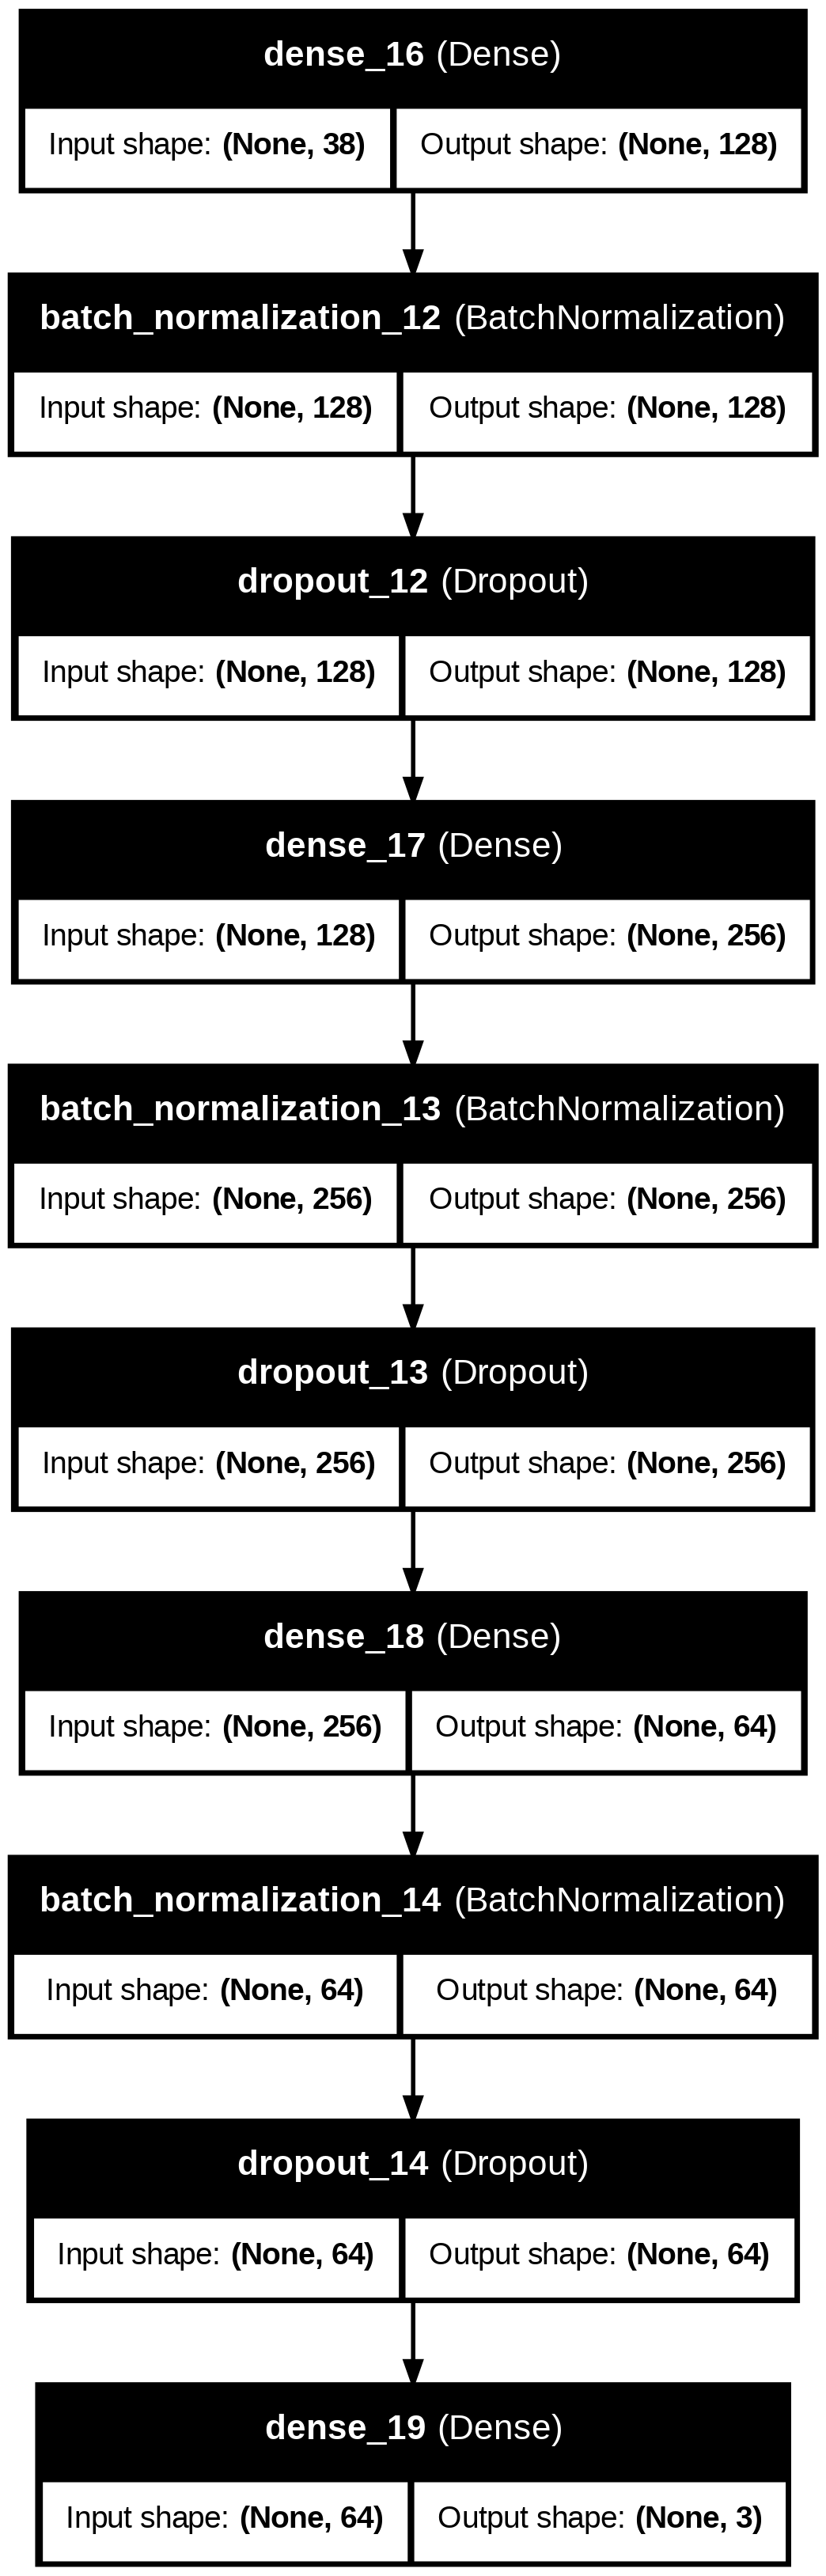

In [49]:
tf.keras.utils.plot_model(
    load_model,
    rankdir='TB',
    show_layer_names=True,
    show_shapes=True,
    expand_nested=True,
    # show_dtype=True,
)

# display(Image('/kaggle/working/model.png'))

In [50]:
## -- Plotting results --
def plot_results(history, plot_dict=None):
    list_ = list(plot_dict.keys())
    val_loss = "val_" + plot_dict[list_[0]]
    val_acc  = "val_" + plot_dict[list_[1]]

    for i, data in tqdm(enumerate(history), total=len(history)):
        loss_results = pd.DataFrame({plot_dict[list_[0]]: data[plot_dict[list_[0]]], val_loss: data[val_loss]})
        acc_results  = pd.DataFrame({plot_dict[list_[1]]: data[plot_dict[list_[1]]], val_acc: data[val_acc]})
    
        plt.figure(figsize=(18, 5))
        marker = "o"
    
        ## -- Plot [1]: Loss --
        plt.subplot(121)
        sns.lineplot(loss_results, x=loss_results.index, 
                     y=loss_results[plot_dict[list_[0]]], label="train", marker=marker)
        sns.lineplot(loss_results, x=loss_results.index, 
                     y=loss_results[val_loss], label="valid", marker=marker)
        plt.title(plot_dict[list_[0]], fontweight="semibold")
        plt.xlabel("Epochs")
        plt.ylabel(plot_dict[list_[0]])
    
        ## -- Plot [2]: Accuracy --
        plt.subplot(122)
        sns.lineplot(acc_results, x=acc_results.index, 
                     y=acc_results[plot_dict[list_[1]]], label="train", marker=marker)
        sns.lineplot(acc_results, x=acc_results.index, 
                     y=acc_results[val_acc], label="valid", marker=marker)
        plt.title(plot_dict[list_[1]], fontweight="semibold")
        plt.xlabel("Epochs")
        plt.ylabel(plot_dict[list_[1]])
    
        stat_ = f"fold_score: {result["fold_scores"][i]:.5f}"
        plt.scatter(x=0, y=0, label=stat_, color="k")
    
        plt.suptitle(f"- FOLD {i+1} -", fontsize=15, fontweight="semibold", color="b")
        plt.legend(loc="best")
        plt.tight_layout()
        plt.show()
        print()

print("Plot function ready")

Plot function ready


  0%|          | 0/5 [00:00<?, ?it/s]

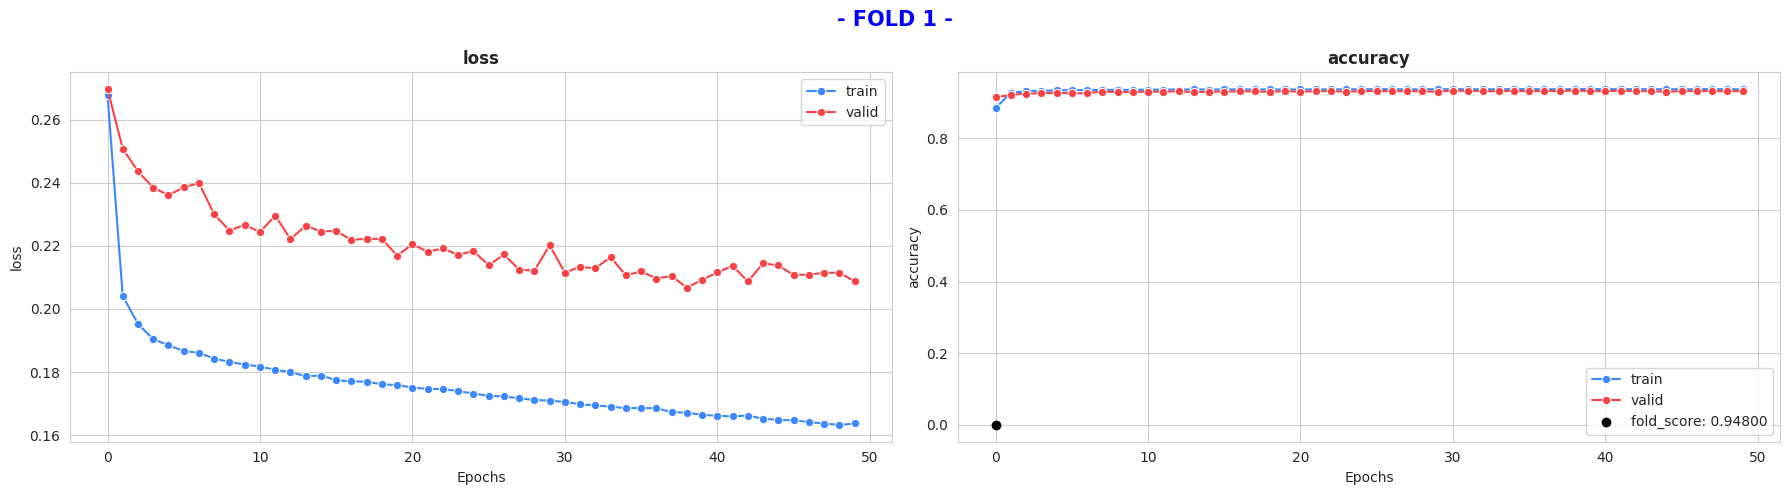

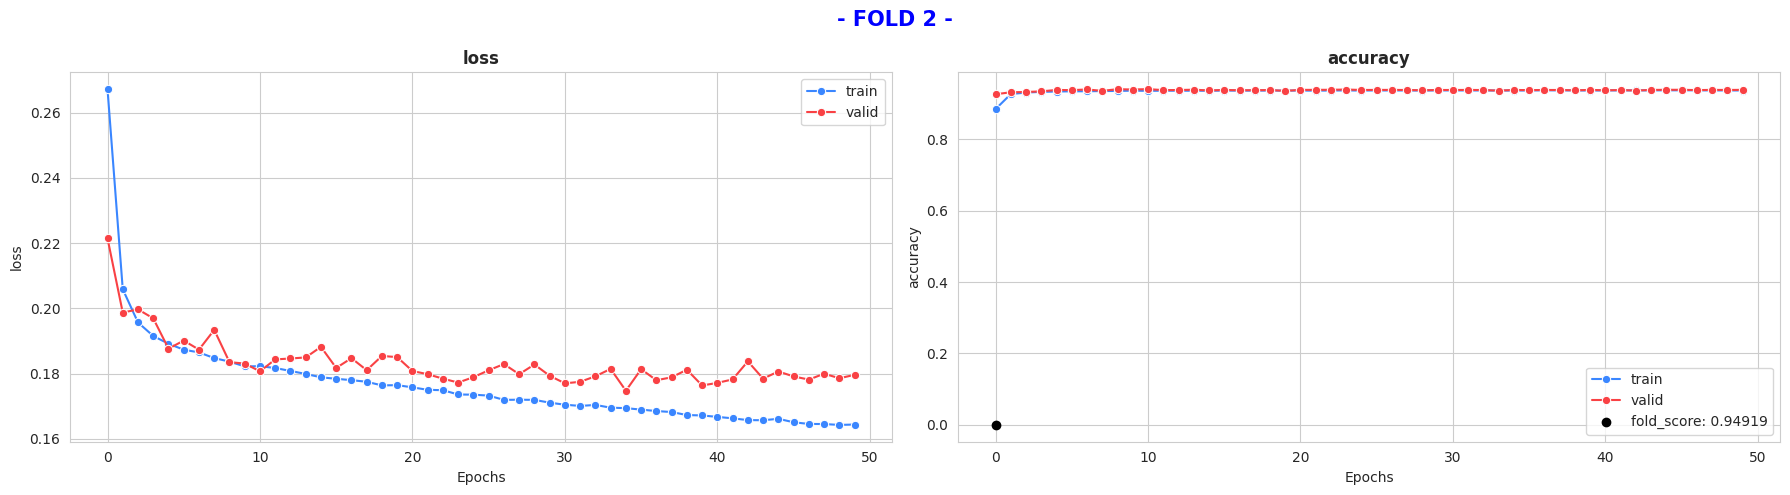

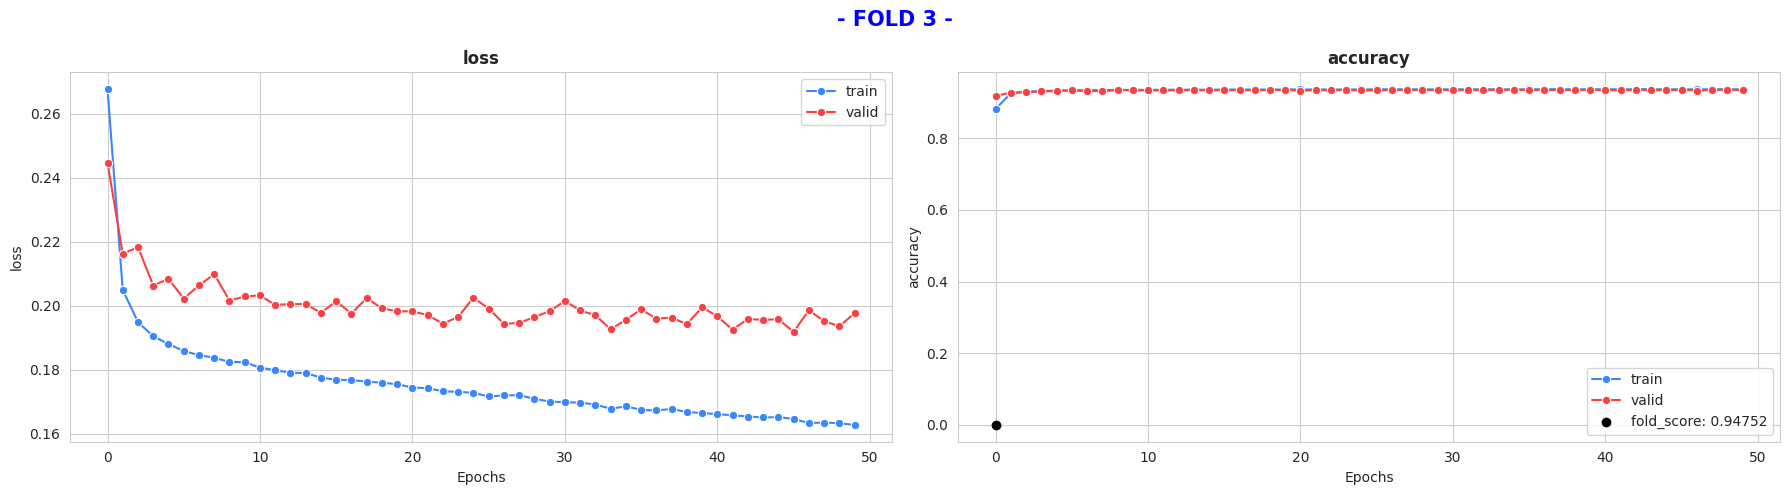

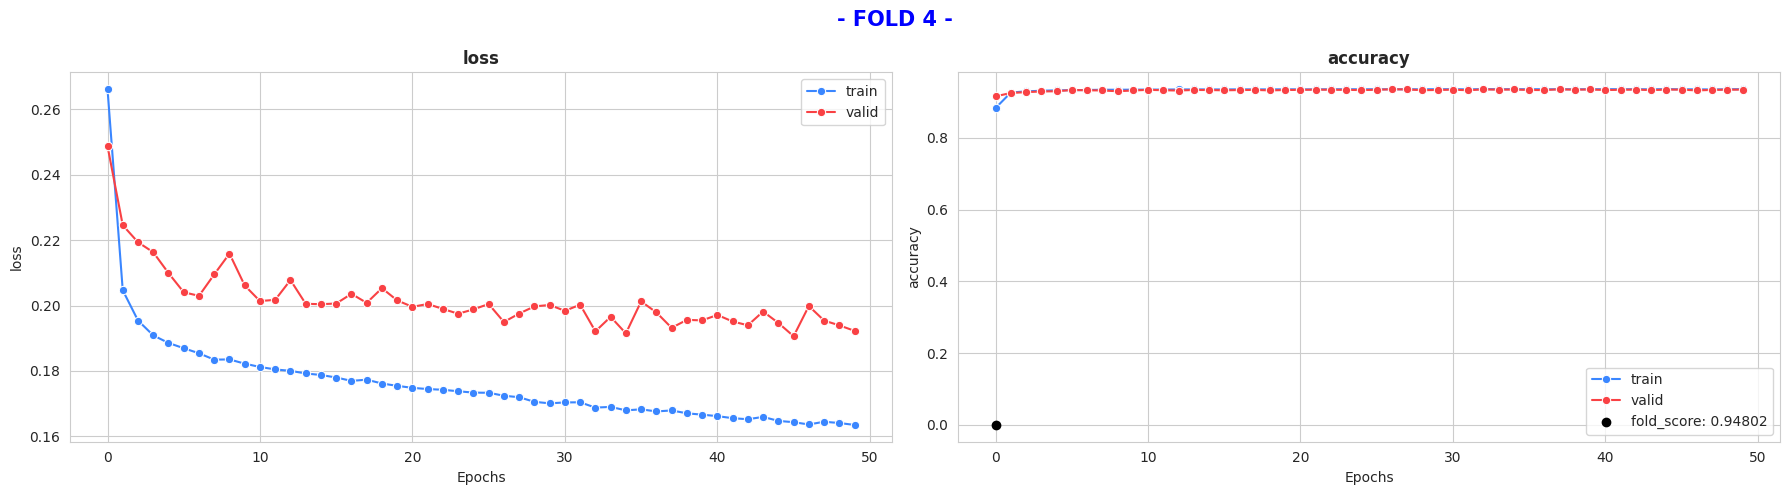

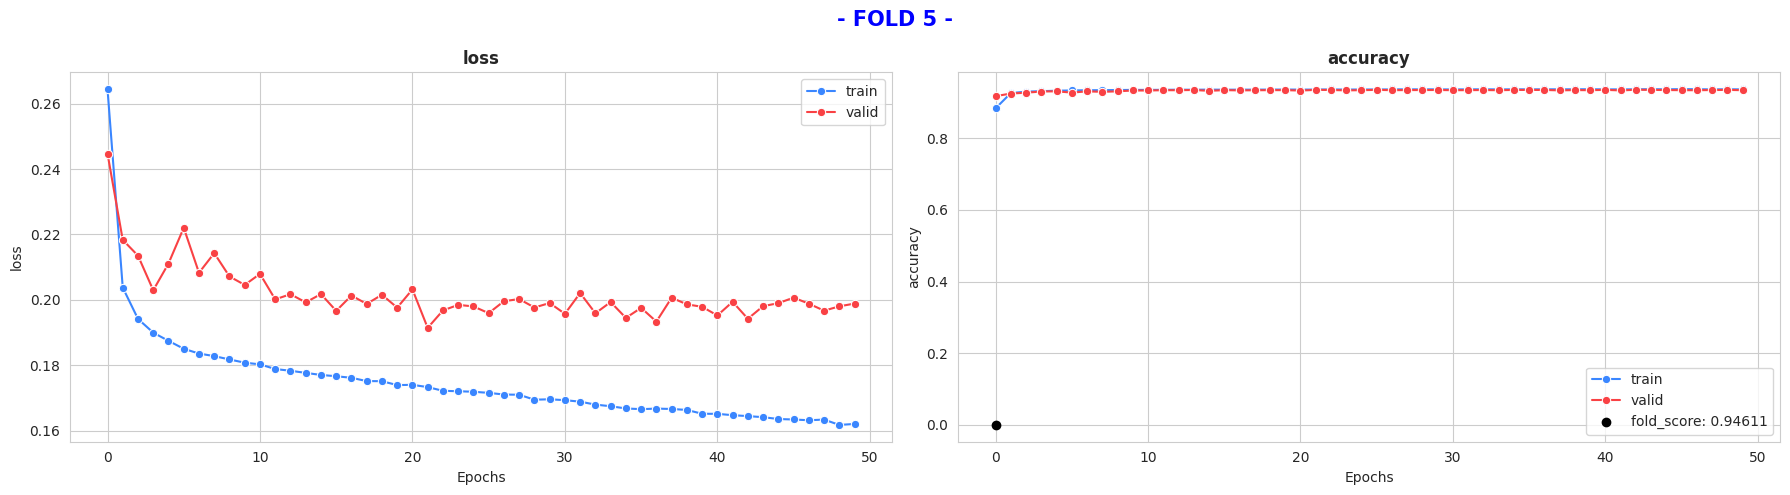

In [51]:
plot_results(result["history"], plot_dict={'loss': 'loss', 'acc': 'accuracy'})

In [52]:
## -- Save predictions/submission --
n = f"{VERS}_{str(result['oof_score']).split('.')[1]}"

np.save(f"oof_{n}_.npy", result['oof_preds'])
np.save(f"test_{n}_.npy", result['test_preds'])

submit[TARGET] = pd.Series(np.argmax(result['test_preds'], axis=1)).map(r_mapping)
submit.to_csv(f"submit_{n}.csv", index=False)

print(f"oof/test/submission files {CFG['YELLOW']}{n}{CFG['RESET']} saved!")
submit

oof/test/submission files scikeras_94777 saved!


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
...,...,...
295748,985836,fit
295749,985837,at-risk
295750,985838,unhealthy
295751,985839,at-risk


In [53]:
# !rm -r /kaggle/working